## Proyecto CNN: Clasificación de imágenes de zacudos transmisores de enfermedades virales en Madre de Dios

### Etapa 1: Tratamiento de datos

In [3]:
import os
import shutil
from pathlib import Path
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [4]:
SOURCE_DIR = Path('MLMI-2024')
TARGET_DIR = Path('dataset')
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# Detectar clases

classes = [d for d in SOURCE_DIR.iterdir() if d.is_dir()]

# Crear carpetas destino
for cls in classes:
    (TARGET_DIR / cls.name).mkdir(parents=True, exist_ok=True)

# Copiar y contar imagenes

image_count = {cls.name: 0 for cls in classes}

for cls in classes:
    for subfolder in cls.iterdir():
        if not subfolder.is_dir():
            continue

        for img_path in subfolder.iterdir():
            if img_path.suffix.lower() in VALID_EXTENSIONS:
                target_path = TARGET_DIR / cls.name / img_path.name
                shutil.copy2(img_path, target_path)
                image_count[cls.name] += 1

# Resumen

print("\nDataset unificado:")
for cls, count in image_count.items():
    print(f" - {cls}: {count} imágenes")


Dataset unificado:
 - Aedes aegypti: 400 imágenes
 - Culex quinquefasciatus: 400 imágenes


### Etapa 2: Visualización de datos

In [5]:
from torchvision import datasets
import matplotlib.pyplot as plt
import random


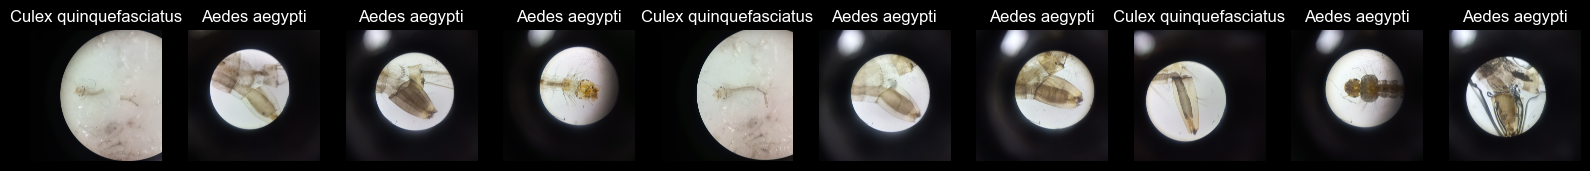

In [6]:
DATASET_DIR = "dataset"
N = 10  # número de imágenes a mostrar

# Cargar dataset
dataset_raw = datasets.ImageFolder(root=DATASET_DIR)

# Seleccionar imágenes aleatorias
indices = random.sample(range(len(dataset_raw)), N)

plt.figure(figsize=(20, 3))

for i, idx in enumerate(indices):
    img, label = dataset_raw[idx]  # img es PIL.Image
    plt.subplot(1, N, i + 1)
    plt.imshow(img)
    plt.title(dataset_raw.classes[label])
    plt.axis("off")

plt.show()

### Etapa 3: Preprocesamiento geométrico

Para esta etapa buscamos definir y ver una previsualización de las imágenes aplicando Crop y Resize respectivamente con el fin de eliminar los bordes negros de las imágenes como se observó anteriormente.

Crop: Intenta recortar automáticamente el campo microscópico (zona clara).

In [7]:
import numpy as np
from PIL import Image


def crop_microscope_field(pil_img, threshold=200):
    """
    Recorta el campo circular del microscopio (zona clara).
    threshold: umbral para detectar fondo claro.
    """
    img_np = np.array(pil_img)

    # Escala de grises
    gray = img_np.mean(axis=2)

    # Máscara del campo (zona clara)
    mask = gray > threshold

    if not mask.any():
        return pil_img

    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    cropped = img_np[y0:y1, x0:x1]
    return Image.fromarray(cropped)


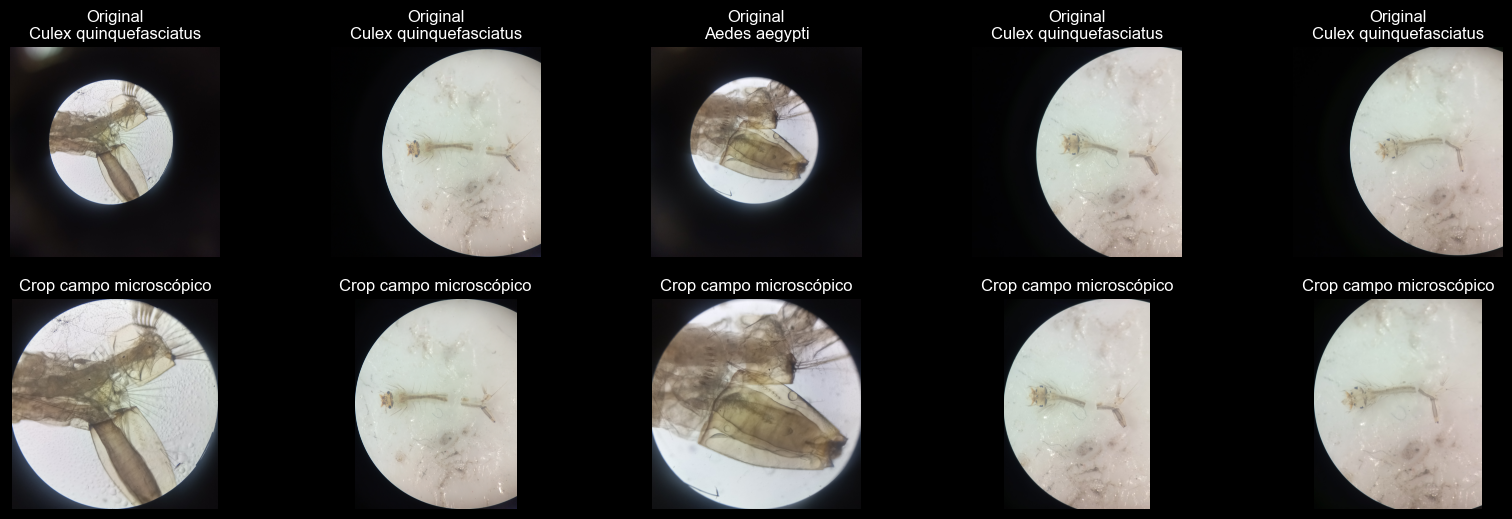

In [8]:
import matplotlib.pyplot as plt
import random
from torchvision import datasets

DATASET_DIR = "dataset"
N = 5

dataset_raw = datasets.ImageFolder(root=DATASET_DIR)

indices = random.sample(range(len(dataset_raw)), N)

plt.figure(figsize=(20, 6))

for i, idx in enumerate(indices):
    img, label = dataset_raw[idx]

    # Original
    plt.subplot(2, N, i + 1)
    plt.imshow(img)
    plt.title(f"Original\n{dataset_raw.classes[label]}")
    plt.axis("off")

    # Crop campo microscópico
    img_cropped = crop_microscope_field(img)
    plt.subplot(2, N, i + 1 + N)
    plt.imshow(img_cropped)
    plt.title("Crop campo microscópico")
    plt.axis("off")

plt.show()

A partir de la comparación visual entre las imágenes originales y las imágenes
procesadas mediante recorte automático del campo microscópico, se observa que
el recorte no genera una mejora consistente en el encuadre ni en la eliminación
de bordes negros, dado que las imágenes ya se encuentran adecuadamente centradas.

Por este motivo, se decide NO incluir esta etapa en el pipeline final de
preprocesamiento, optando únicamente por un redimensionamiento uniforme y
normalización de las imágenes.

In [9]:
from PIL import Image
import torchvision.transforms.functional as F


class ResizeWithPadding:
    """
    Redimensiona la imagen preservando la relación de aspecto
    y aplica padding para obtener una imagen cuadrada.
    """
    def __init__(self, target_size=224, fill=0):
        self.target_size = target_size
        self.fill = fill

    def __call__(self, image):
        # Tamaño original
        width, height = image.size

        # Escala para preservar aspecto
        scale = self.target_size / max(width, height)
        new_width = int(width * scale)
        new_height = int(height * scale)

        # Resize
        resized_image = image.resize(
            (new_width, new_height),
            resample=Image.Resampling.BILINEAR
        )

        # Cálculo del padding
        pad_w = self.target_size - new_width
        pad_h = self.target_size - new_height

        padding = [
            pad_w // 2,                 # izquierda
            pad_h // 2,                 # arriba
            pad_w - pad_w // 2,         # derecha
            pad_h - pad_h // 2          # abajo
        ]

        # Aplicar padding
        padded_image = F.pad(
            resized_image,
            padding,
            fill=self.fill
        )

        return padded_image


Dimensiones originales: (3456, 3456)
Dimensiones después de resize + padding: (240, 240)


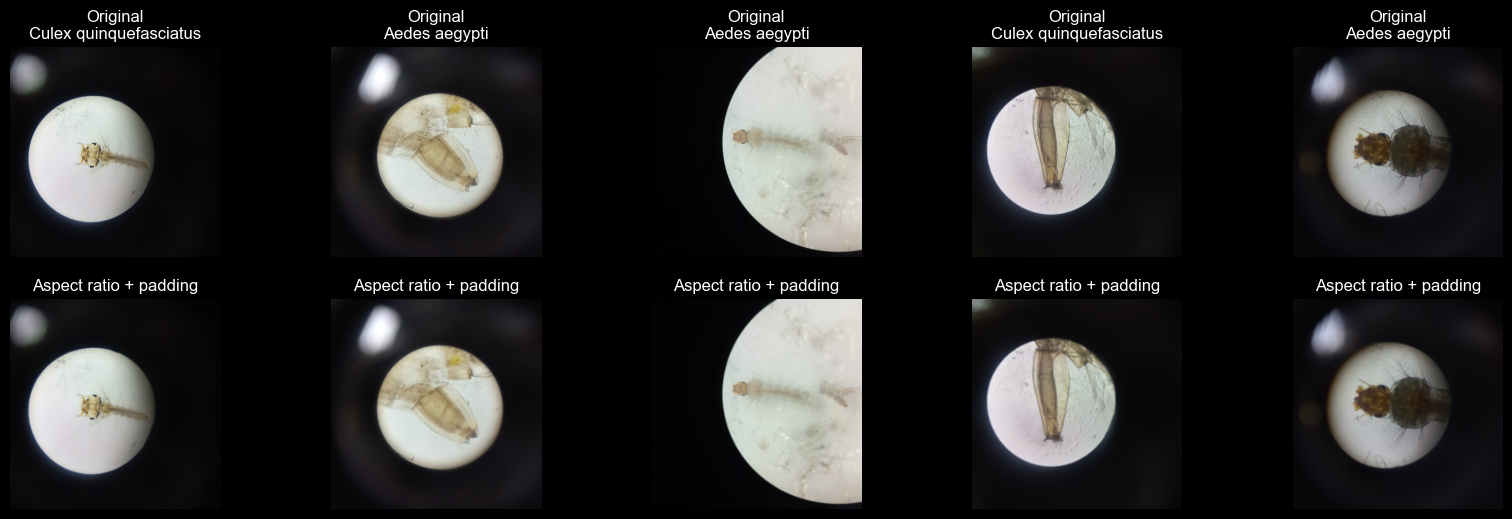

In [10]:
from torchvision import datasets

TARGET_SIZE = 240

dataset_raw = datasets.ImageFolder(root=DATASET_DIR)
resize_pad = ResizeWithPadding(target_size=TARGET_SIZE)

indices = random.sample(range(len(dataset_raw)), N)

idx = indices[0]
img, label = dataset_raw[idx]

print("Dimensiones originales:", img.size)

img_padded = resize_pad(img)
print("Dimensiones después de resize + padding:", img_padded.size)

plt.figure(figsize=(20, 6))

for i, idx in enumerate(indices):
    img, label = dataset_raw[idx]

    # Imagen original
    plt.subplot(2, N, i + 1)
    plt.imshow(img)
    plt.title(f"Original\n{dataset_raw.classes[label]}")
    plt.axis("off")

    # Imagen con resize + padding
    img_padded = resize_pad(img)
    plt.subplot(2, N, i + 1 + N)
    plt.imshow(img_padded)
    plt.title("Aspect ratio + padding")
    plt.axis("off")

plt.show()

Aunque el redimensionamiento no produce cambios visuales drásticos,
este sí estandariza las dimensiones de entrada a 240×240 píxeles
manteniendo la relación de aspecto original. La ausencia de distorsión
visual confirma que la estrategia de resize con padding preserva la
morfología de las larvas, lo cual es deseable para tareas de clasificación.

“Si bien en la literatura se reporta el uso de redimensionamientos tempranos debido a las características del conjunto de datos original (640×480 píxeles), en el presente estudio se evaluó dicha estrategia sobre imágenes de mayor resolución (3456×3456 píxeles), no observándose una mejora visual ni geométrica significativa. En consecuencia, se decidió no aplicar un redimensionamiento destructivo durante el preprocesamiento geométrico, preservando la resolución original de las imágenes.”

### Etapa 4: División del conjunto de datos

In [11]:
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split

In [12]:
SOURCE_DIR = Path("dataset")
TARGET_DIR = Path("dataset_split")

In [13]:
image_paths = []
labels = []

classes = sorted([d.name for d in SOURCE_DIR.iterdir() if d.is_dir()])

class_to_idx = {cls: i for i, cls in enumerate(classes)}

for cls in classes:
    for img in (SOURCE_DIR / cls).iterdir():
        if img.suffix.lower() in VALID_EXTENSIONS:
            image_paths.append(img)
            labels.append(class_to_idx[cls])

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

val_size = 0.15 / (0.15 + 0.15)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=(1 - val_size),
    stratify=y_temp,
    random_state=42
)

In [15]:
for split in ["train", "val", "test"]:
    for cls in classes:
        (TARGET_DIR / split / cls).mkdir(parents=True, exist_ok=True)

In [16]:
def copy_files(files, labels, split_name):
    for img_path, label in zip(files, labels):
        cls_name = classes[label]
        shutil.copy2(
            img_path,
            TARGET_DIR / split_name / cls_name / img_path.name
        )

copy_files(X_train, y_train, "train")
copy_files(X_val, y_val, "val")
copy_files(X_test, y_test, "test")

# RESUMEN

print("Split completado con train_test_split\n")

for cls in classes:
    for split in ["train", "val", "test"]:
        count = len(list((TARGET_DIR / split / cls).iterdir()))
        print(f"{split.upper()} | {cls}: {count}")
    print("-" * 40)

Split completado con train_test_split

TRAIN | Aedes aegypti: 280
VAL | Aedes aegypti: 60
TEST | Aedes aegypti: 60
----------------------------------------
TRAIN | Culex quinquefasciatus: 280
VAL | Culex quinquefasciatus: 60
TEST | Culex quinquefasciatus: 60
----------------------------------------


Con el fin de garantizar una comparación justa entre los modelos propuestos, todos los experimentos fueron realizados utilizando la misma división del conjunto de datos en entrenamiento, validación y prueba. De este modo, las diferencias observadas en el desempeño de los modelos se atribuyen exclusivamente a las arquitecturas empleadas.

El split actual será utilizado para desarrollar y comparar los modelos:

1. CNN
2. CNN + ELM
3. ResNet18
4. EfficientNet_Lite0

### Etapa 5: Definición de arquitecturas CNN

En esta etapa se definió una red neuronal convolucional como extractor de características, inspirada en la arquitectura propuesta en la literatura, compuesta por cinco bloques de convolución y agrupación máxima. La CNN se emplea como base común para los modelos CNN pura y CNN-ELM.

Revisar los packages models

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

if not torch.cuda.is_available():
    raise RuntimeError(" CUDA no está disponible. Este notebook requiere GPU NVIDIA.")

device = torch.device("cuda")
print(" GPU detectada:", torch.cuda.get_device_name(0))


 GPU detectada: NVIDIA GeForce RTX 5060 Laptop GPU


In [18]:
DATASET_DIR = Path("dataset_split")

SAVE_DIR = Path("results/cnn")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = SAVE_DIR / "cnn_pure.pth"
HISTORY_PATH = SAVE_DIR / "history.pt"

FIGURES_DIR = SAVE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS = 100
LEARNING_RATE = 1e-3
PATIENCE = 15

In [19]:
# Variables de control

best_val_acc = 0.0
patience_counter = 0

In [20]:
# ===============================
# TRANSFORMS
# ===============================
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ===============================
# DATASETS
# ===============================
train_ds = datasets.ImageFolder(DATASET_DIR / "train", transform=transform_train)
val_ds   = datasets.ImageFolder(DATASET_DIR / "val",   transform=transform_eval)
test_ds  = datasets.ImageFolder(DATASET_DIR / "test",  transform=transform_eval)

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Clases:", train_ds.classes)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Clases: ['Aedes aegypti', 'Culex quinquefasciatus']
Train: 560 | Val: 120 | Test: 120


In [21]:
from models.cnn import CNNPure


model = CNNPure(num_classes=2).to(device)

if MODEL_PATH.exists():
    print(" Modelo entrenado encontrado. Cargando pesos...")
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()
else:
    print(" No se encontró modelo previo. Se entrenará desde cero.")

 Modelo entrenado encontrado. Cargando pesos...


In [22]:
def pytorch_summary(model, input_size=(3, 224, 224)):
    hooks = []
    summary = []

    def hook(module, input, output):
        if isinstance(module, (nn.Sequential, nn.ModuleList)) or module == model:
            return

        params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        out_shape = tuple(output.shape)
        summary.append((module.__class__.__name__, out_shape, params))

    for m in model.modules():
        hooks.append(m.register_forward_hook(hook))

    with torch.no_grad():
        model(torch.randn(1, *input_size).to(device))

    for h in hooks:
        h.remove()

    print("------------------------------------------------------------")
    print(f"{'Layer':<20} {'Output Shape':<25} {'Params'}")
    print("============================================================")
    for layer, shape, params in summary:
        print(f"{layer:<20} {str(shape):<25} {params}")
    print("============================================================")
    total = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total}")
    print("------------------------------------------------------------")

pytorch_summary(model)


------------------------------------------------------------
Layer                Output Shape              Params
Conv2d               (1, 32, 224, 224)         896
BatchNorm2d          (1, 32, 224, 224)         64
ReLU                 (1, 32, 224, 224)         0
MaxPool2d            (1, 32, 112, 112)         0
Conv2d               (1, 64, 112, 112)         18496
BatchNorm2d          (1, 64, 112, 112)         128
ReLU                 (1, 64, 112, 112)         0
MaxPool2d            (1, 64, 56, 56)           0
Conv2d               (1, 128, 56, 56)          73856
BatchNorm2d          (1, 128, 56, 56)          256
ReLU                 (1, 128, 56, 56)          0
MaxPool2d            (1, 128, 28, 28)          0
Conv2d               (1, 256, 28, 28)          295168
BatchNorm2d          (1, 256, 28, 28)          512
ReLU                 (1, 256, 28, 28)          0
AdaptiveAvgPool2d    (1, 256, 1, 1)            0
CNNFeatureExtractor  (1, 256)                  389376
Linear               (1, 

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [24]:
def train_one_epoch(model, dataloader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in dataloader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (outputs.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def validate(model, dataloader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item() * x.size(0)
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


In [25]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Guardar MEJOR modelo

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        improved = "look up!"
    else:
        patience_counter += 1
        improved = ""

    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} {improved}"
    )

    # EARLY STOPPING

    if patience_counter >= PATIENCE:
        print(
            f"\n Early stopping activado en epoch {epoch+1}\n"
            f"   Mejor Val Acc: {best_val_acc:.4f}"
        )
        break

# Guardar historial

torch.save(history, HISTORY_PATH)

print(f"\nMejor modelo guardado en: {MODEL_PATH}")
print(f" Historial guardado en: {HISTORY_PATH}")


Epoch [001/100] | Train Acc: 0.9536 | Val Acc: 0.8000 look up!
Epoch [002/100] | Train Acc: 0.9536 | Val Acc: 0.9750 look up!
Epoch [003/100] | Train Acc: 0.9375 | Val Acc: 0.8000 
Epoch [004/100] | Train Acc: 0.9589 | Val Acc: 0.8667 
Epoch [005/100] | Train Acc: 0.9661 | Val Acc: 0.9583 
Epoch [006/100] | Train Acc: 0.9679 | Val Acc: 0.9250 
Epoch [007/100] | Train Acc: 0.9804 | Val Acc: 0.9583 
Epoch [008/100] | Train Acc: 0.9750 | Val Acc: 0.7583 
Epoch [009/100] | Train Acc: 0.9696 | Val Acc: 0.8917 
Epoch [010/100] | Train Acc: 0.9482 | Val Acc: 0.8583 
Epoch [011/100] | Train Acc: 0.9661 | Val Acc: 0.5250 
Epoch [012/100] | Train Acc: 0.9589 | Val Acc: 0.8250 
Epoch [013/100] | Train Acc: 0.9607 | Val Acc: 0.7417 
Epoch [014/100] | Train Acc: 0.9732 | Val Acc: 0.5083 
Epoch [015/100] | Train Acc: 0.9696 | Val Acc: 0.6333 
Epoch [016/100] | Train Acc: 0.9732 | Val Acc: 0.6333 
Epoch [017/100] | Train Acc: 0.9643 | Val Acc: 0.9000 

 Early stopping activado en epoch 17
   Mejor Va

In [26]:
if HISTORY_PATH.exists():
    print("Historial encontrado. Cargando...")
    history = torch.load(HISTORY_PATH)
else:
    raise RuntimeError(" No se encontró history.pt. El modelo debe entrenarse al menos una vez.")

Historial encontrado. Cargando...


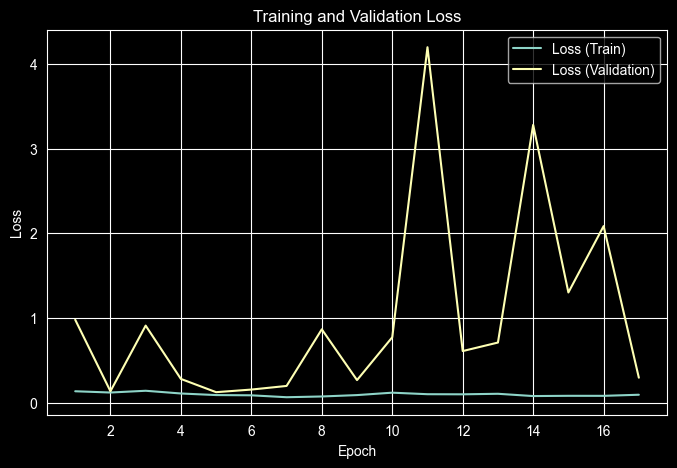

In [27]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Loss (Train)")
plt.plot(epochs, history["val_loss"], label="Loss (Validation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(FIGURES_DIR / "loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()


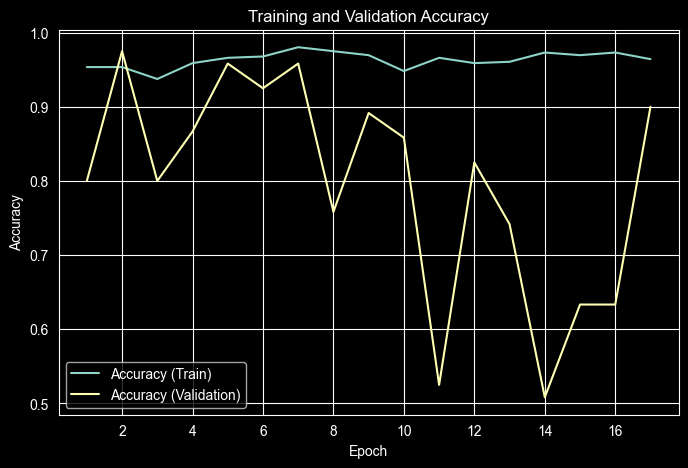

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Accuracy (Train)")
plt.plot(epochs, history["val_acc"], label="Accuracy (Validation)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(FIGURES_DIR / "accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

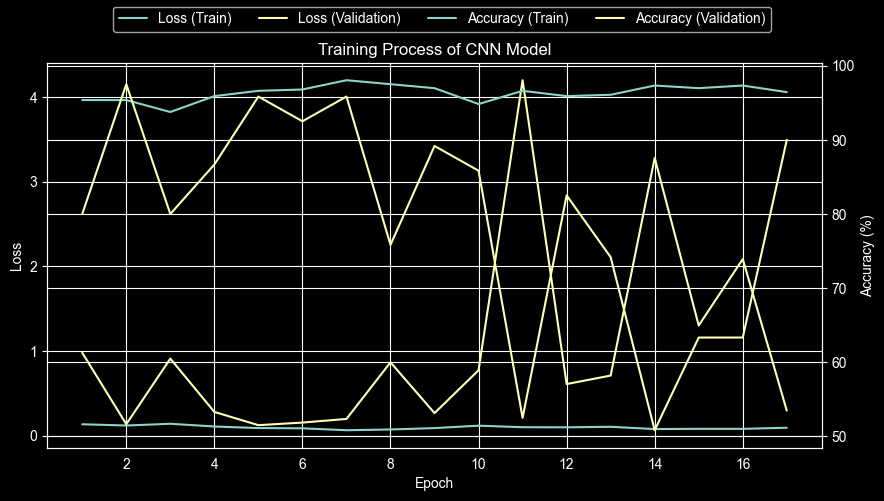

In [29]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.plot(epochs, history["train_loss"], label="Loss (Train)")
ax1.plot(epochs, history["val_loss"], label="Loss (Validation)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy (%)")
ax2.plot(epochs, [a * 100 for a in history["train_acc"]], label="Accuracy (Train)")
ax2.plot(epochs, [a * 100 for a in history["val_acc"]], label="Accuracy (Validation)")

fig.legend(loc="upper center", ncol=4)
plt.title("Training Process of CNN Model")

plt.savefig(FIGURES_DIR / "training_process.png", dpi=300, bbox_inches="tight")
plt.show()


Se diseñó una red neuronal convolucional inspirada en arquitecturas CNN clásicas tipo AlexNet, adaptada mediante técnicas modernas de regularización y pooling global.

#### Etapa 6: Modelos y búsqueda de hiperparámetros óptimos con Optimización Bayeseana